# Flash Calculations for Mixtures


In [2]:
from thermo import ChemicalConstantsPackage, CEOSGas, CEOSLiquid, PRMIX, FlashVL
from thermo.interaction_parameters import IPDB

In [3]:
constants, properties = ChemicalConstantsPackage.from_IDs(['water', 'methanol'])
print(constants.Tcs, constants.Pcs, constants.omegas)

[647.096, 513.38] [22064000.0, 8215850.0] [0.3443, 0.5625]


In [4]:
kijs = IPDB.get_ip_asymmetric_matrix('ChemSep PR', constants.CASs, 'kij')
print(kijs)

[[0.0, -0.0778], [-0.0778, 0.0]]


In [5]:
eos_kwargs = {'Pcs': constants.Pcs, 'Tcs': constants.Tcs, 'omegas': constants.omegas, 'kijs': kijs}
gas = CEOSGas(PRMIX, eos_kwargs=eos_kwargs, HeatCapacityGases=properties.HeatCapacityGases)
liquid = CEOSLiquid(PRMIX, eos_kwargs=eos_kwargs, HeatCapacityGases=properties.HeatCapacityGases)

In [6]:
activity = liquid.rho()
print(activity)

29500.11624204427


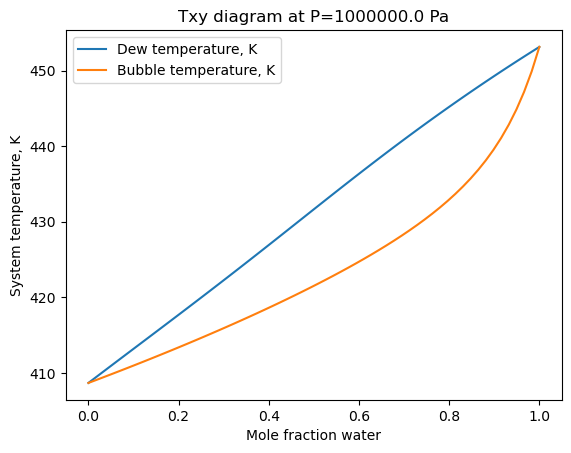

In [7]:
flasher = FlashVL(constants, properties, liquid=liquid, gas=gas)
#flasher.plot_Pxy(273.15+100, pts = 60)
flasher.plot_Txy(1e6,pts=60)